# SNN Online Learning

**Train a spiking neural network using ES-D-RTRL**

Spiking Neural Networks (SNNs) process information through discrete spike events, mimicking the communication mechanism of biological neurons. Unlike traditional artificial neural networks that operate on continuous activations, SNNs emphasize the timing and frequency of spikes, making them inherently suited for temporal data processing.

**Online learning** is a natural fit for SNNs because they process inputs sequentially, one time step at a time. Instead of storing the entire computation graph for backpropagation through time (BPTT), online learning algorithms update weight gradients incrementally at each time step. This eliminates the need to unroll the network over the full sequence length, resulting in constant memory usage with respect to sequence length.

In this tutorial, we use `braintrace.pp_prop` (historically exposed as `braintrace.ES_D_RTRL`), an online estimator that factorizes the eligibility trace into input and output components. Its trace memory is **O(B(I+O))** (where B is batch size, I is input dimension, and O is output dimension), subject to the documented model and operator assumptions.

**What you will learn:**

1. Build an SNN model using `brainstate` neurons and `braintrace.nn` layers.
2. Configure online learning with `braintrace.pp_prop` / `braintrace.ES_D_RTRL`.
3. Accumulate gradients over a spike sequence and update the model.
4. Distinguish the D-RTRL and input/output-factorized trace regimes.

## 1. Setup

First, let us import the required packages. The key components are:
- `brainstate`: provides neuron models (LIF), state management, and JAX-based transformations
- `braintrace`: provides online learning algorithms and ETP-aware neural network layers
- `braintools`: provides initializers, optimizers, surrogate gradient functions, and metrics
- `brainunit`: provides physical units (ms, mV, etc.) for biologically meaningful parameters

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax
import jax.numpy as jnp
import brainstate
import braintools
import braintrace
import brainunit as u
import brainpy.state
import matplotlib.pyplot as plt
import warnings

brainstate.random.seed(31)

## 2. SNN Model

We build a simple recurrent SNN with the following architecture:

1. **Input + Recurrent Projection**: A `braintrace.nn.Linear` layer that projects the concatenation of input spikes and recurrent spikes into the hidden layer. Using `braintrace.nn.Linear` (instead of a plain matrix multiply) marks this projection for participation in online learning via ETP primitives.

2. **LIF Neuron**: A Leaky Integrate-and-Fire neuron from `brainpy.state.LIF`. The LIF neuron integrates its input current, fires a spike when the membrane potential exceeds a threshold, and then resets. We use `braintools.surrogate.ReluGrad()` as the surrogate gradient function for differentiability.

3. **Readout**: A `braintrace.nn.LeakyRateReadout` that applies leaky integration to the recurrent spikes and produces a continuous output signal for classification. This layer is also ETP-aware.

The recurrent connectivity is achieved by concatenating the neuron's own spike output with the external input at each time step.

In [2]:
class LIF_SNN(brainstate.nn.Module):
    """A simple recurrent SNN with LIF neurons for online learning."""

    def __init__(self, n_in, n_rec, n_out, tau_mem=20. * u.ms, tau_out=20. * u.ms):
        super().__init__()

        # Input + recurrent projection (ETP-aware: participates in online learning).
        # Weights are in current units so that ``I * R`` lands in mV inside the LIF
        # neuron (LIF integrates ``-V + I*R``; ``mA * ohm = mV`` matches V_th below).
        self.linear = braintrace.nn.Linear(
            n_in + n_rec, n_rec,
            w_init=braintools.init.KaimingNormal(scale=50., unit=u.mA),
            b_init=braintools.init.ZeroInit(unit=u.mA),
        )

        # LIF neuron with surrogate gradient for differentiability.
        self.neuron = brainpy.state.LIF(
            n_rec,
            tau=tau_mem,
            R=1. * u.ohm,
            V_th=0.1 * u.mV,
            V_reset=0. * u.mV,
            V_rest=0. * u.mV,
            spk_fun=braintools.surrogate.ReluGrad(),
            spk_reset='soft',
        )

        # Readout layer (ETP-aware: participates in online learning).
        self.readout = braintrace.nn.LeakyRateReadout(
            n_rec, n_out,
            tau=tau_out,
            w_init=braintools.init.KaimingNormal(),
        )

    def update(self, spike_input):
        # Concatenate input spikes with recurrent spikes.
        rec_spk = self.neuron.get_spike()
        x = jnp.concatenate([spike_input, rec_spk], axis=-1)

        # Linear projection -> LIF neuron dynamics -> readout.
        self.neuron(self.linear(x))
        return self.readout(self.neuron())

Let us verify that the model can be instantiated and produce output for a single sample.

In [3]:
with brainstate.environ.context(dt=1. * u.ms):
    model = LIF_SNN(n_in=50, n_rec=128, n_out=10)
    brainstate.nn.init_all_states(model)

    # A short structured spike train verifies non-zero network activity.
    test_inputs = brainstate.random.bernoulli(
        0.6, size=(20, 50)
    ).astype(jnp.float32)
    outputs = brainstate.transform.for_loop(model, test_inputs)
    output = outputs[-1]
    print(f"Output shape: {output.shape}")
    print(f"Output values: {output}")
    print(f"Mean |output|: {float(jnp.mean(jnp.abs(outputs))):.4f}")

Output shape: (10,)
Output values: [  1.0803026  -17.27935      8.622799     5.3416724   10.71552
   7.327959    -5.94303      0.88145703  -2.8744242   -8.330857  ]
Mean |output|: 4.4554


## 3. Training with ES-D-RTRL

We set up online learning using `braintrace.compile` with `braintrace.pp_prop` (also exposed as `braintrace.ES_D_RTRL` and `braintrace.IODimVjpAlgorithm`). The `decay_or_rank` parameter controls the trace approximation:

* **`decay_or_rank=float` in (0, 1)** -- exponentially-smoothed trace. Larger values retain a longer history but may be less stable; this short teaching task uses `0.5`. Memory cost: `O(B * (I + O))` per layer.
* **`decay_or_rank=int >= 1`** -- an alternative parameterization of the same decay, using `decay = (rank - 1) / (rank + 1)`. It does not allocate multiple rank factors, so memory remains `O(B * (I + O))`.

Use the float form to set the decay directly, or the integer form to select the corresponding decay through the documented conversion. Neither form creates an independent rank-versus-memory trade-off.

`braintrace.compile(model, braintrace.ES_D_RTRL, x0, batch_size=B, vmap=True, decay_or_rank=0.5)` initialises per-sample states, builds the ETP graph, and returns a vmapped learner — no separate `init_all_states`, `compile_graph`, or `Vmap` calls are needed.

`braintrace.D_RTRL` is the alternative parameter-dimensional estimator. It stores parameter-shaped eligibility traces and can use substantially more memory; neither estimator is generally gradient-equivalent to BPTT outside its documented assumptions.

In [4]:
def make_spike_classification_batches(
    n_updates=200, n_steps=100, batch_size=40, n_in=50, n_out=10
):
    """Create a learnable task whose classes activate disjoint channels."""
    labels = jnp.arange(batch_size, dtype=jnp.int32) % n_out
    channel_class = jnp.arange(n_in) * n_out // n_in
    active = labels[:, None] == channel_class[None, :]
    firing_probability = jnp.where(active, 0.6, 0.0)
    inputs = brainstate.random.bernoulli(
        firing_probability,
        size=(n_updates, n_steps, batch_size, n_in),
    ).astype(jnp.float32)
    targets = jnp.broadcast_to(labels, (n_updates, batch_size))
    return inputs, targets


def train_snn(input_batches, target_batches, n_rec=128, lr=3e-3):
    """Train a recurrent SNN using pp-prop over fixed structured batches."""
    n_in = input_batches.shape[-1]
    n_out = int(target_batches.max()) + 1
    batch_size = input_batches.shape[2]

    with brainstate.environ.context(dt=1. * u.ms):
        brainstate.random.seed(37)
        model = LIF_SNN(n_in, n_rec, n_out)
        opt = braintools.optim.Adam(lr)
        weights = model.states(brainstate.ParamState)
        opt.register_trainable_weights(weights)

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=r"ETP primitive .*")
            learner = braintrace.compile(
                model, braintrace.pp_prop, input_batches[0, 0],
                batch_size=batch_size, vmap=True, decay_or_rank=0.5,
            )

        @brainstate.transform.jit
        def train_step(inputs, targets):
            brainstate.nn.reset_all_states(model, batch_size=batch_size)
            learner.reset_state(batch_size=batch_size)

            def loss_fn(inp):
                output = learner(inp)
                loss = braintools.metric.softmax_cross_entropy_with_integer_labels(
                    output, targets
                ).mean()
                return loss, output

            def scan_step(previous_grads, inp):
                current_grads, current_loss, output = brainstate.transform.grad(
                    loss_fn, weights, has_aux=True, return_value=True
                )(inp)
                next_grads = jax.tree.map(
                    lambda total, current: total + current,
                    previous_grads, current_grads,
                )
                return next_grads, (current_loss, output)

            zero_grads = jax.tree.map(jnp.zeros_like, weights.to_dict_values())
            grads, (step_losses, outputs) = brainstate.transform.scan(
                scan_step, zero_grads, inputs
            )
            grads = brainstate.nn.clip_grad_norm(grads, 1.0)
            opt.update(grads)
            predictions = jnp.argmax(jnp.sum(outputs, axis=0), axis=-1)
            accuracy = jnp.mean(predictions == targets)
            return step_losses.mean(), accuracy

        return brainstate.transform.for_loop(
            train_step, input_batches, target_batches
        )

Let us run the training loop. Note that the first epoch will be slower due to JAX's JIT compilation.

In [5]:
brainstate.random.seed(41)
spike_inputs, spike_targets = make_spike_classification_batches()
losses, accuracies = train_snn(spike_inputs, spike_targets)
print(f"Update   0, Loss: {float(losses[0]):.4f}, Accuracy: {float(accuracies[0]):.3f}")
print(f"Update  50, Loss: {float(losses[50]):.4f}, Accuracy: {float(accuracies[50]):.3f}")
print(f"Update 100, Loss: {float(losses[100]):.4f}, Accuracy: {float(accuracies[100]):.3f}")
print(f"Update 150, Loss: {float(losses[150]):.4f}, Accuracy: {float(accuracies[150]):.3f}")
print(f"Update 199, Loss: {float(losses[-1]):.4f}, Accuracy: {float(accuracies[-1]):.3f}")

Update   0, Loss: 2.5441, Accuracy: 0.100
Update  50, Loss: 0.5428, Accuracy: 0.950
Update 100, Loss: 0.1173, Accuracy: 1.000
Update 150, Loss: 0.0697, Accuracy: 1.000
Update 199, Loss: 0.0636, Accuracy: 1.000


Plot both loss and accuracy over 200 parameter updates. Each update scans one 100-time-step sequence batch. On this fixed-seed task, accuracy rises well above the 10% chance level and the final loss is lower than the initial loss. The curve need not decrease monotonically: `pp_prop` is an approximate online estimator, and each update uses a different pre-generated batch. Treat the joint loss-and-accuracy evidence as a reproducible teaching check, not as a convergence guarantee.

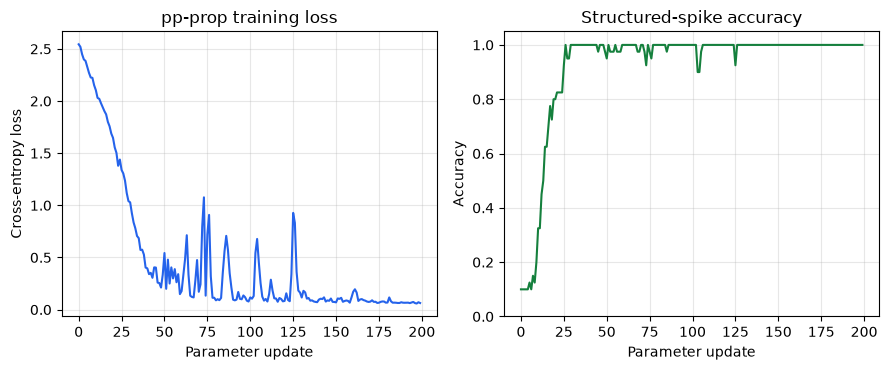

In [6]:
with plt.style.context("default"), plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
    axes[0].plot(losses, color="#2563eb")
    axes[0].set(xlabel="Parameter update", ylabel="Cross-entropy loss")
    axes[0].set_title("pp-prop training loss")
    axes[1].plot(accuracies, color="#15803d")
    axes[1].set(xlabel="Parameter update", ylabel="Accuracy", ylim=(0, 1.05))
    axes[1].set_title("Structured-spike accuracy")
    for axis in axes:
        axis.grid(True, alpha=0.3)
    fig.tight_layout()
plt.show()

## 4. Key differences: D-RTRL vs pp-prop

BrainTrace provides two parameterizations of online eligibility-trace estimation. Their gradients and memory costs differ, and neither is generally equivalent to BPTT outside its documented assumptions.

| Aspect | D-RTRL (`ParamDimVjpAlgorithm`) | pp-prop (`pp_prop`, historically `ES_D_RTRL`) |
|---|---|---|
| **Eligibility trace** | Parameter-shaped trace with a diagonal hidden-Jacobian approximation | Input/output-factorized trace with exponential smoothing |
| **Trace memory** | O(B * theta), where theta is the number of traced parameters | O(B * (I + O)), where I and O are input and output dimensions |
| **Main approximation** | Diagonal hidden-to-hidden Jacobian structure | Input/output factorization plus exponential smoothing |
| **Recommended use** | When parameter-shaped trace memory is feasible | When lower trace memory is required and the factorization assumptions are acceptable |
| **BrainTrace API** | `braintrace.compile(model, braintrace.D_RTRL, x0, batch_size=B)` | `braintrace.compile(model, braintrace.pp_prop, x0, batch_size=B, decay_or_rank=0.5)` |

A float `decay_or_rank` value sets the pp-prop decay directly. A positive integer selects the corresponding decay through `decay = (rank - 1) / (rank + 1)`; it does not allocate that many low-rank factors. Validate either estimator against BPTT on a reduced version of the intended model before relying on gradient fidelity.

```python
# D-RTRL: parameter-shaped trace
learner = braintrace.compile(model, braintrace.D_RTRL, x0, batch_size=B)

# pp-prop: input/output-factorized trace
learner = braintrace.compile(model, braintrace.pp_prop, x0, batch_size=B, decay_or_rank=0.5)
```

## 5. Summary

In this tutorial, we demonstrated how to train a spiking neural network with online learning using BrainTrace. Here are the key takeaways:

1. **Model Construction**: Use `braintrace.nn.Linear` and `braintrace.nn.LeakyRateReadout` for layers that should participate in online learning (ETP-aware). Combine them with spiking neuron models from `brainpy.state` (e.g., `LIF`).

2. **Online Learning Setup**: Use `braintrace.compile(model, braintrace.ES_D_RTRL, x0, batch_size=B, vmap=True, decay_or_rank=0.5)` to initialise states, compile the ETP graph, and return a vmapped learner in one call. Then use `brainstate.transform.grad` to compute gradients at each time step.

3. **Scalability**: ES-D-RTRL achieves O(B(I+O)) memory complexity, making it practical for large spiking networks. The `decay_or_rank` parameter controls the trace approximation quality.

4. **Batching**: `braintrace.compile(..., batch_size=B, vmap=True)` handles per-sample state initialisation and vmapped execution automatically.

For more advanced topics, including training on real neuromorphic datasets (N-MNIST) and comparing online learning with BPTT, see:
- [pp_prop algorithm tutorial](pp_prop.ipynb)
- [Key Concepts](../quickstart/concepts.ipynb)